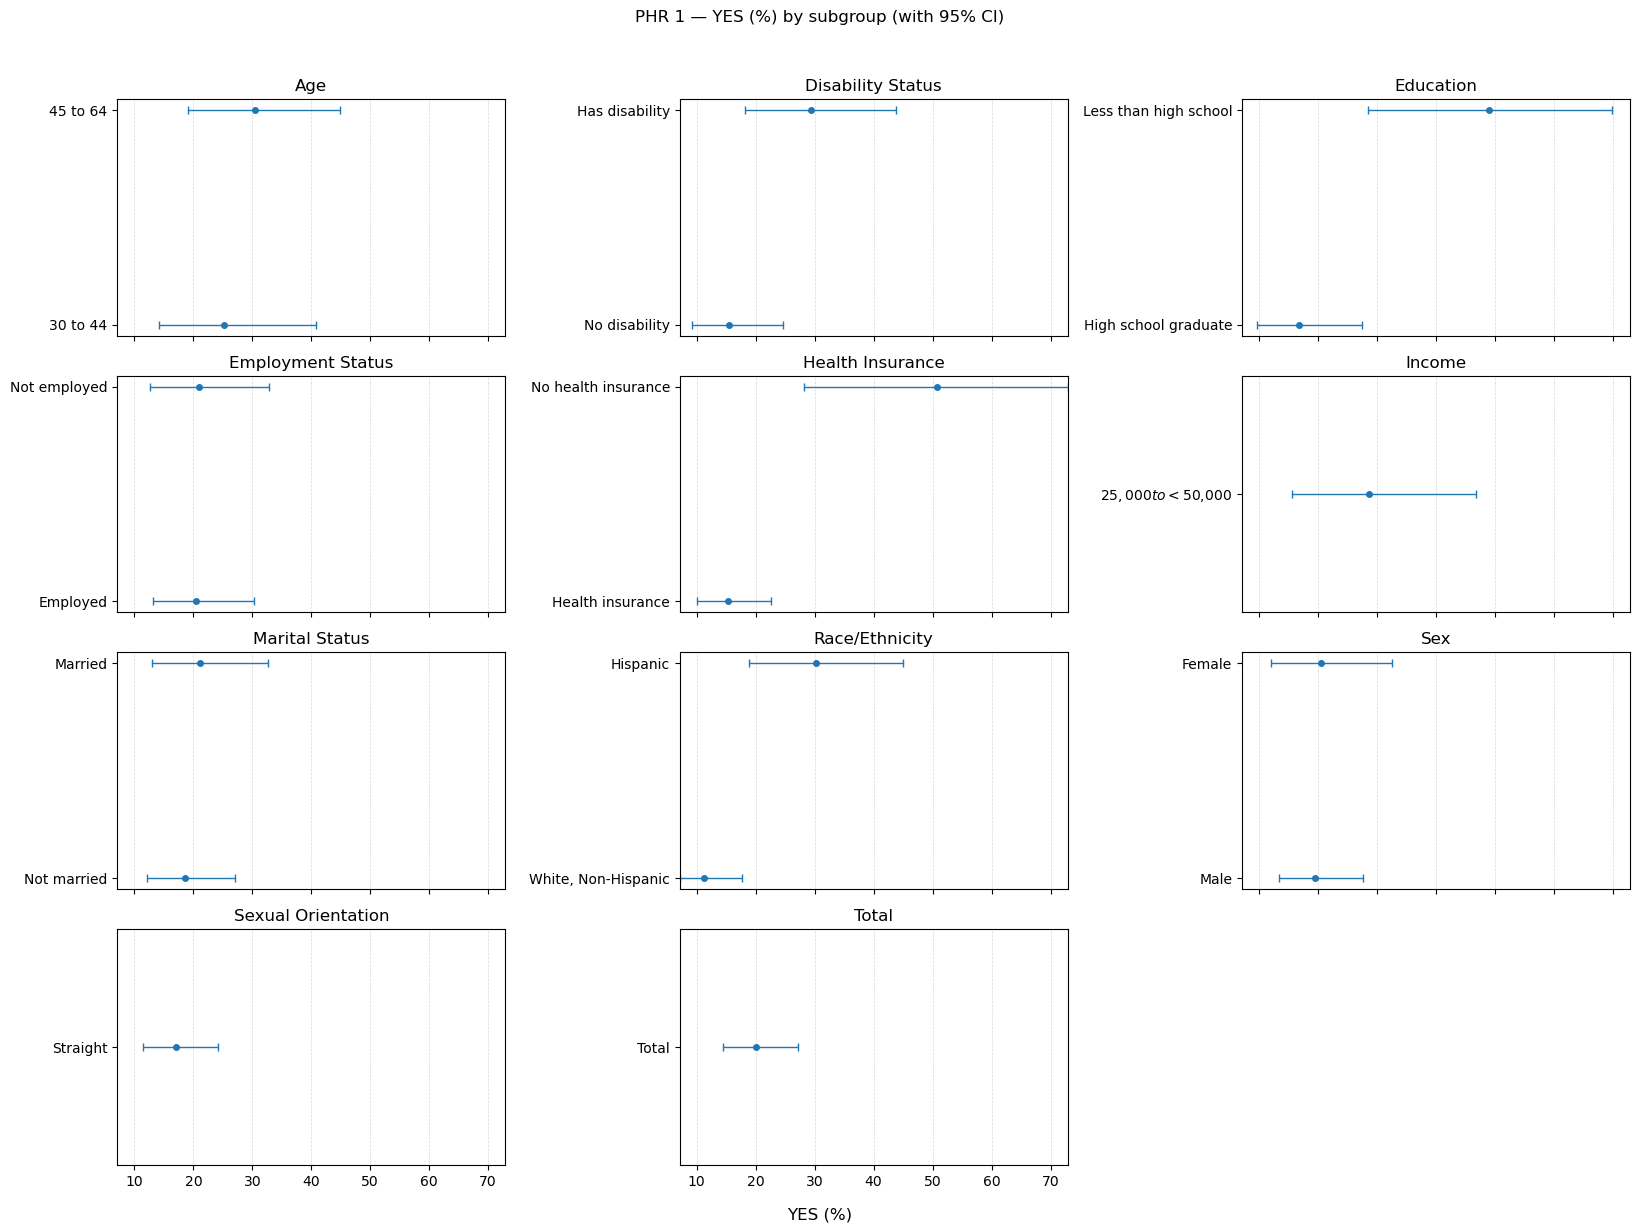

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

df = pd.read_csv("data/brfss/combined_with_phr.csv")

# --- filter PHR=1, YES ---
df1 = df.loc[(df["PHR"] == 1) & (df["answer"] == "YES")].copy()

# --- coerce numerics safely ---
for col in ["pct", "low", "high"]:
    df1[col] = pd.to_numeric(df1[col], errors="coerce")

df1["n"] = (
    df1["n"].astype(str)
    .str.replace(",", "", regex=False)
    .replace({"N": np.nan, "": np.nan, "nan": np.nan})
)
df1["n"] = pd.to_numeric(df1["n"], errors="coerce")

# Keep only rows usable for errorbars
df1 = df1.dropna(subset=["pct", "low", "high", "group", "level"])
df1 = df1[(df1["high"] >= df1["pct"]) & (df1["pct"] >= df1["low"])]

groups = sorted(df1["group"].unique())
if len(groups) == 0:
    raise ValueError("No groups found after filtering. Check PHR/answer filters and missing values.")

# --- layout (auto grid) ---
n_groups = len(groups)
ncols = 3  # change to 2 or 4 if you want
nrows = math.ceil(n_groups / ncols)

# Global x-limits for comparability
xmin = float(np.nanmin(df1["low"]))
xmax = float(np.nanmax(df1["high"]))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5.5 * ncols, 3.0 * nrows),
    sharex=True
)

# axes can be 2D array or 1D; flatten for easy indexing
axes = np.array(axes).reshape(-1)

for i, g in enumerate(groups):
    ax = axes[i]
    sub = df1[df1["group"] == g].sort_values("pct").copy()

    y = np.arange(len(sub))
    x = sub["pct"].to_numpy()
    xerr = np.vstack([(x - sub["low"].to_numpy()), (sub["high"].to_numpy() - x)])

    ax.errorbar(x, y, xerr=xerr, fmt="o", capsize=3, elinewidth=1, markersize=4)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["level"].astype(str))
    ax.set_title(g)
    ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.set_xlim(xmin, xmax)

# Hide any unused subplots
for j in range(n_groups, len(axes)):
    axes[j].axis("off")

fig.suptitle("PHR 1 — YES (%) by subgroup (with 95% CI)", y=1.02)
fig.supxlabel("YES (%)")
fig.tight_layout()
plt.show()

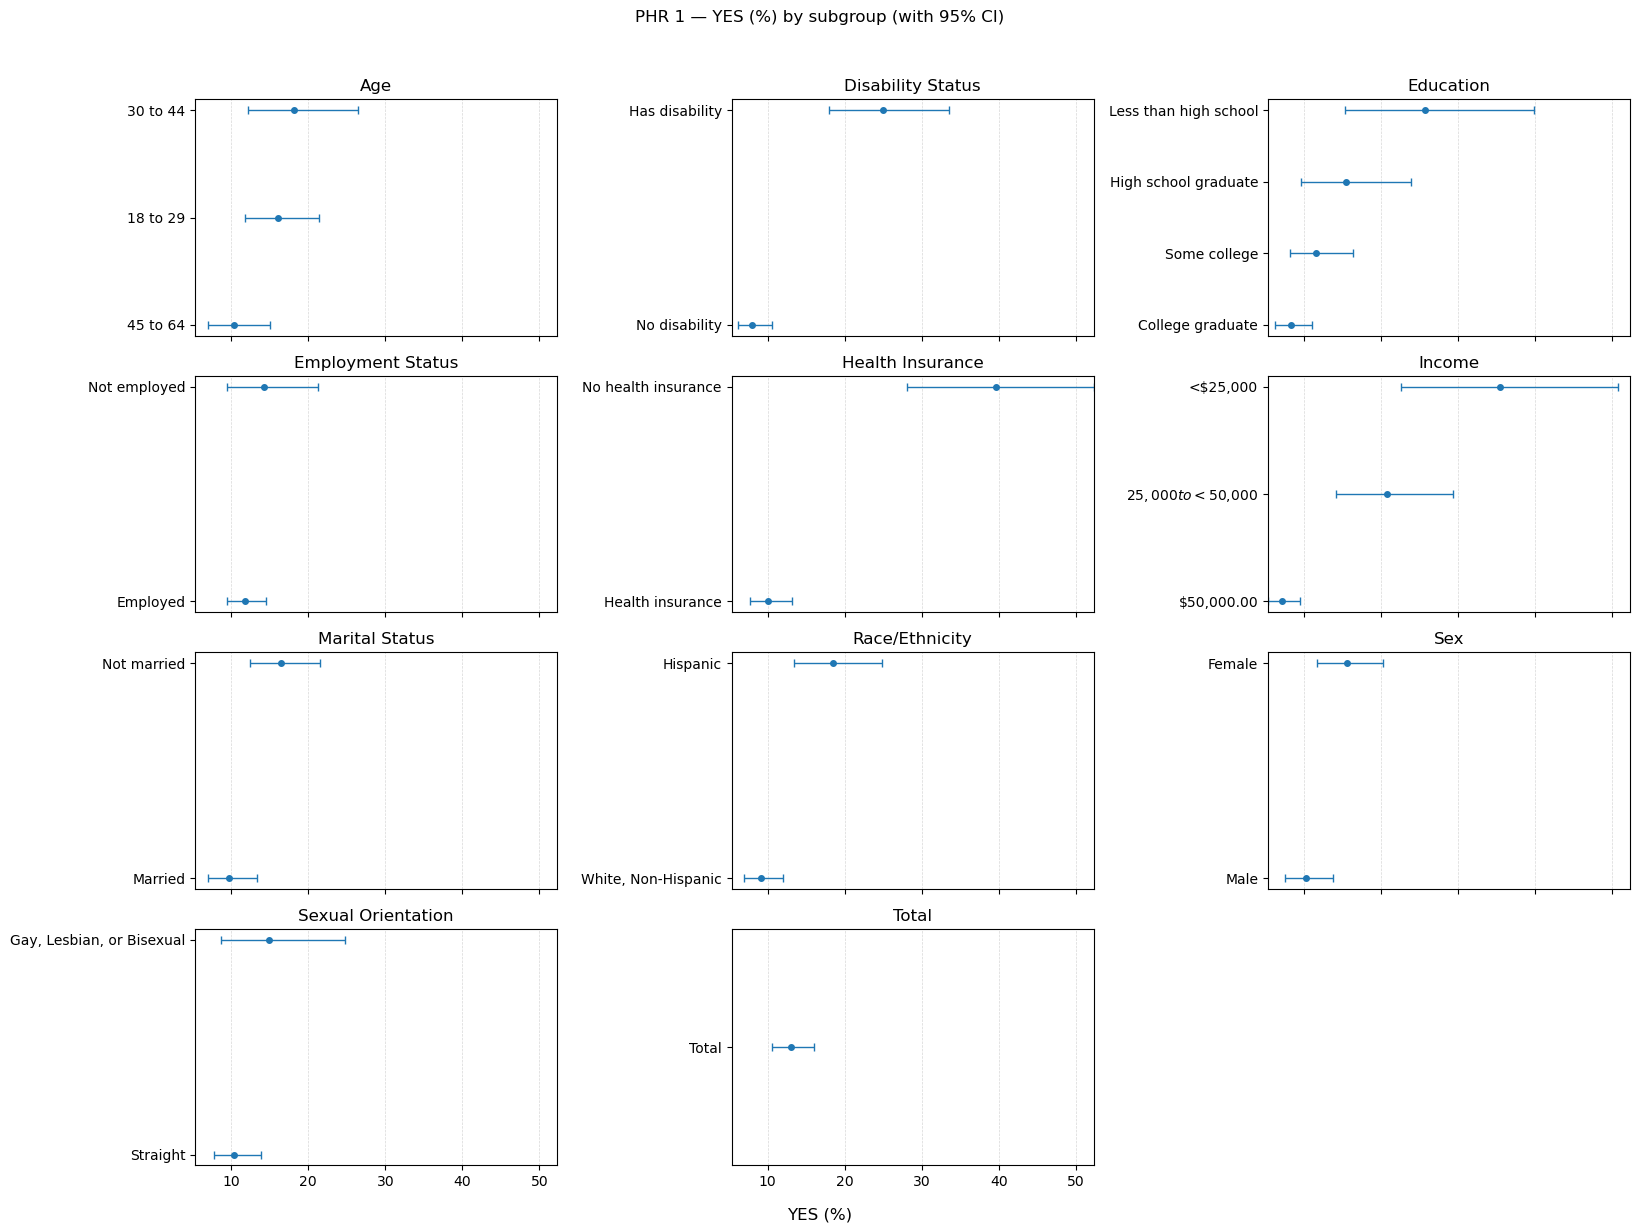

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

df = pd.read_csv("data/brfss/combined_with_phr.csv")

# --- filter PHR=1, YES ---
df1 = df.loc[(df["PHR"] == 7) & (df["answer"] == "YES")].copy()

# --- coerce numerics safely ---
for col in ["pct", "low", "high"]:
    df1[col] = pd.to_numeric(df1[col], errors="coerce")

df1["n"] = (
    df1["n"].astype(str)
    .str.replace(",", "", regex=False)
    .replace({"N": np.nan, "": np.nan, "nan": np.nan})
)
df1["n"] = pd.to_numeric(df1["n"], errors="coerce")

# Keep only rows usable for errorbars
df1 = df1.dropna(subset=["pct", "low", "high", "group", "level"])
df1 = df1[(df1["high"] >= df1["pct"]) & (df1["pct"] >= df1["low"])]

groups = sorted(df1["group"].unique())
if len(groups) == 0:
    raise ValueError("No groups found after filtering. Check PHR/answer filters and missing values.")

# --- layout (auto grid) ---
n_groups = len(groups)
ncols = 3  # change to 2 or 4 if you want
nrows = math.ceil(n_groups / ncols)

# Global x-limits for comparability
xmin = float(np.nanmin(df1["low"]))
xmax = float(np.nanmax(df1["high"]))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5.5 * ncols, 3.0 * nrows),
    sharex=True
)

# axes can be 2D array or 1D; flatten for easy indexing
axes = np.array(axes).reshape(-1)

for i, g in enumerate(groups):
    ax = axes[i]
    sub = df1[df1["group"] == g].sort_values("pct").copy()

    y = np.arange(len(sub))
    x = sub["pct"].to_numpy()
    xerr = np.vstack([(x - sub["low"].to_numpy()), (sub["high"].to_numpy() - x)])

    ax.errorbar(x, y, xerr=xerr, fmt="o", capsize=3, elinewidth=1, markersize=4)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["level"].astype(str))
    ax.set_title(g)
    ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.set_xlim(xmin, xmax)

# Hide any unused subplots
for j in range(n_groups, len(axes)):
    axes[j].axis("off")

fig.suptitle("PHR 1 — YES (%) by subgroup (with 95% CI)", y=1.02)
fig.supxlabel("YES (%)")
fig.tight_layout()
plt.show()